In [9]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    str    
 1   date_heure    605 non-null    str    
 2   id_capteur    605 non-null    str    
 3   batiment      605 non-null    str    
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    str    
dtypes: float64(4), str(5)
memory usage: 42.7 KB


In [13]:
df.describe()


,temperature,humidite,pression,consommation
count,599.000000,600.00000,600.000000,600.000000
mean,24.878314,64.92620,1012.221900,208.675417
std,4.059576,10.76905,10.599042,72.243567
min,-18.500000,28.52000,850.000000,18.120000
25%,22.570000,58.17250,1006.790000,160.177500
50%,24.860000,65.37500,1012.855000,206.150000
75%,27.275000,71.61500,1017.827500,254.127500
max,58.700000,145.00000,1038.430000,875.000000


## Partie 1 – Graphique linéaire (Line Plot)

### 1) Évolution de la température en fonction du temps

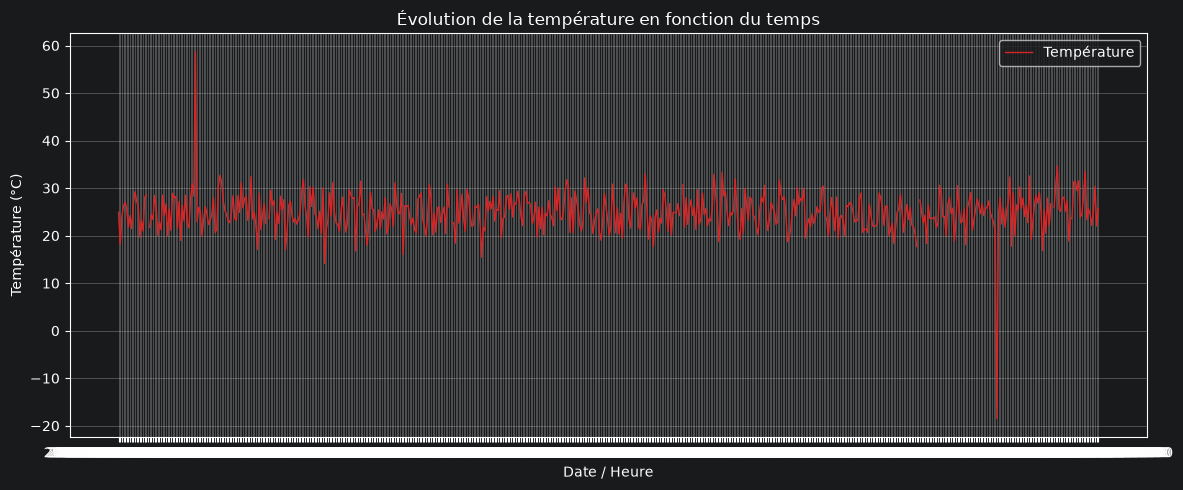

In [14]:
df_sorted = df.sort_values("date_heure")

plt.figure(figsize=(12, 5))
plt.plot(df_sorted["date_heure"], df_sorted["temperature"],
         color="tab:red", linewidth=1, label="Température")
plt.title("Évolution de la température en fonction du temps")
plt.xlabel("Date / Heure")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 2) Valeurs anormales identifiées visuellement

En observant la courbe, deux points sortent nettement du nuage principal (qui oscille globalement
entre 15°C et 35°C) :

- une valeur **très négative (≈ -18,5 °C)** le 27/01/2026, sur le bâtiment B004,
- une valeur **très élevée (≈ 58,7 °C)** le 06/01/2026, sur le bâtiment B004.

Ces deux mesures sont physiquement incohérentes pour un environnement intérieur/extérieur normal :
ce sont très probablement des **erreurs de capteur** (dysfonctionnement, mauvaise calibration ou bruit
de transmission) plutôt que de vraies variations climatiques.

In [15]:
# Vérification chiffrée des valeurs extrêmes repérées visuellement
df[(df["temperature"] < 0) | (df["temperature"] > 45)][
    ["date_heure", "batiment", "id_capteur", "temperature"]
]


,date_heure,batiment,id_capteur,temperature
487,2026-01-27 09:00:00,B004,C010,-18.5
502,2026-01-06 23:00:00,B004,C012,58.7
